[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/02_gradient_descent/first_principles.ipynb)

# 02 Gradient Descent — First Principles

> **Goal:** Build gradient descent and its variants from scratch in NumPy.  
> Understand convergence, learning rate effects, momentum, and adaptive methods.

**Prerequisites:**
- [theory.md](theory.md) — convergence conditions, smoothness, momentum, Adam
- [01 Linear Regression](../01_linear_regression/README.md) — the normal equation alternative

**Phase:** 1 | **Status:** ✅ Complete

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

---
## 1. Problem Setup — WHY

Most ML objectives have no closed-form solution. We need an iterative method
that uses local gradient information to find the minimum.

Let's start with a simple 2D quadratic: $f(x, y) = x^2 + 4y^2$.
The minimum is at $(0, 0)$, but we'll watch GD find it step by step.

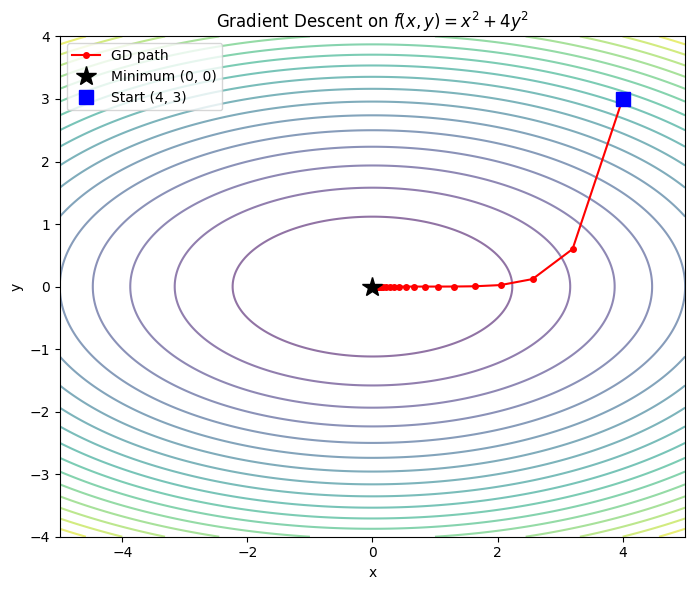

After 20 steps: w = [0.046117, 0.000000]
f(w) = 0.00212676


In [2]:
# 2D quadratic: f(x,y) = x^2 + 4y^2
# Gradient: [2x, 8y]
# Hessian eigenvalues: 2 and 8 → M = 8, mu = 2, kappa = 4

def f_quad(w):
    """Quadratic objective f(x,y) = x^2 + 4y^2."""
    return w[0]**2 + 4 * w[1]**2

def grad_quad(w):
    """Gradient of f(x,y) = x^2 + 4y^2."""
    return np.array([2 * w[0], 8 * w[1]])

# Manual GD steps from (4, 3) with alpha = 0.1
w = np.array([4.0, 3.0])
alpha = 0.1
path = [w.copy()]

for step in range(20):
    g = grad_quad(w)
    w = w - alpha * g
    path.append(w.copy())

path = np.array(path)

# Visualize the trajectory on contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
zz = xx**2 + 4 * yy**2
ax.contour(xx, yy, zz, levels=20, cmap="viridis", alpha=0.6)
ax.plot(path[:, 0], path[:, 1], "ro-", markersize=4, linewidth=1.5, label="GD path")
ax.plot(0, 0, "k*", markersize=15, label="Minimum (0, 0)")
ax.plot(path[0, 0], path[0, 1], "bs", markersize=10, label="Start (4, 3)")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Gradient Descent on $f(x,y) = x^2 + 4y^2$")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"After 20 steps: w = [{w[0]:.6f}, {w[1]:.6f}]")
print(f"f(w) = {f_quad(w):.8f}")

---
## 2. Mathematical Core — WHAT

The gradient descent update:
$$\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)$$

**Convergence condition:** For an $M$-smooth function, we need $\alpha < 2/M$.

For our quadratic $f(x,y) = x^2 + 4y^2$:
- Hessian = $\text{diag}(2, 8)$, so $M = 8$
- Convergence requires $\alpha < 2/8 = 0.25$
- Optimal step size: $\alpha = 1/M = 0.125$

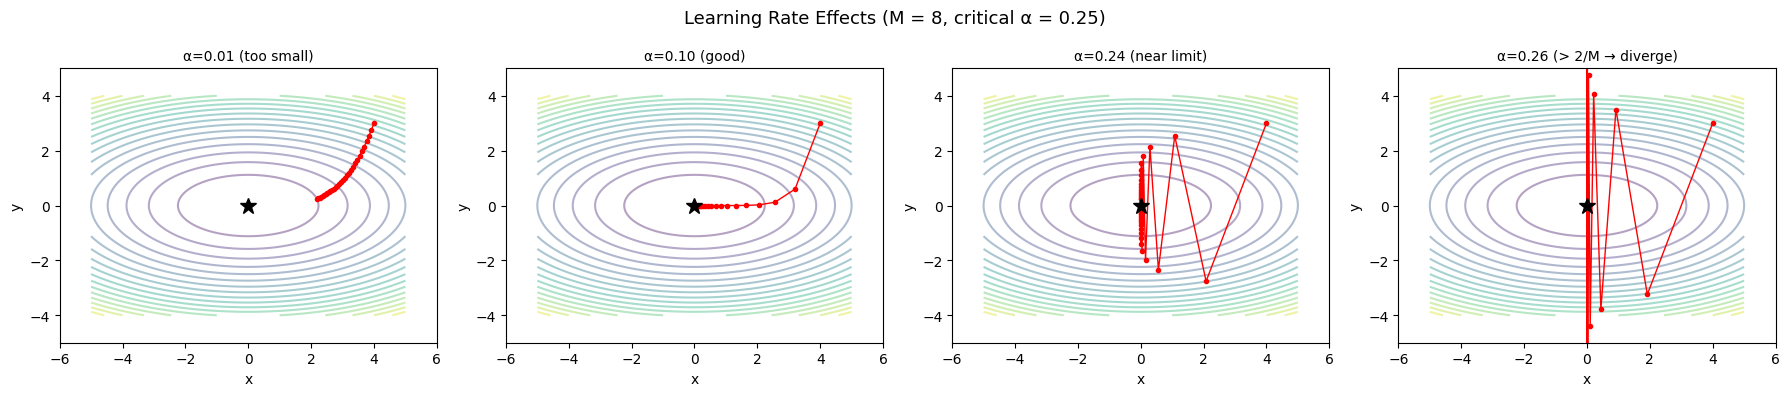

In [3]:
# Learning rate effects: too small, just right, too large, divergent
learning_rates = [0.01, 0.1, 0.24, 0.26]
labels = ["α=0.01 (too small)", "α=0.10 (good)", "α=0.24 (near limit)", "α=0.26 (> 2/M → diverge)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, lr, label in zip(axes, learning_rates, labels):
    w = np.array([4.0, 3.0])
    path = [w.copy()]
    diverged = False
    for _ in range(30):
        g = grad_quad(w)
        w = w - lr * g
        if np.any(np.abs(w) > 100):
            diverged = True
            break
        path.append(w.copy())
    path = np.array(path)

    ax.contour(xx, yy, zz, levels=20, cmap="viridis", alpha=0.4)
    ax.plot(path[:, 0], path[:, 1], "ro-", markersize=3, linewidth=1)
    ax.plot(0, 0, "k*", markersize=12)
    ax.set_title(label, fontsize=10)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-5, 5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if diverged:
        ax.text(0, 0, "DIVERGED", ha="center", va="center",
                fontsize=14, color="red", fontweight="bold")

plt.suptitle("Learning Rate Effects (M = 8, critical α = 0.25)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Solution Method — HOW

### Convergence analysis on the quadratic

For $f(x,y) = x^2 + 4y^2$ with $M=8$, $\mu=2$, $\kappa=4$:

- **Theory predicts:** with $\alpha = 1/M = 0.125$, the error decays as $(1 - \mu/M)^t = 0.75^t$
- Let's verify this experimentally.

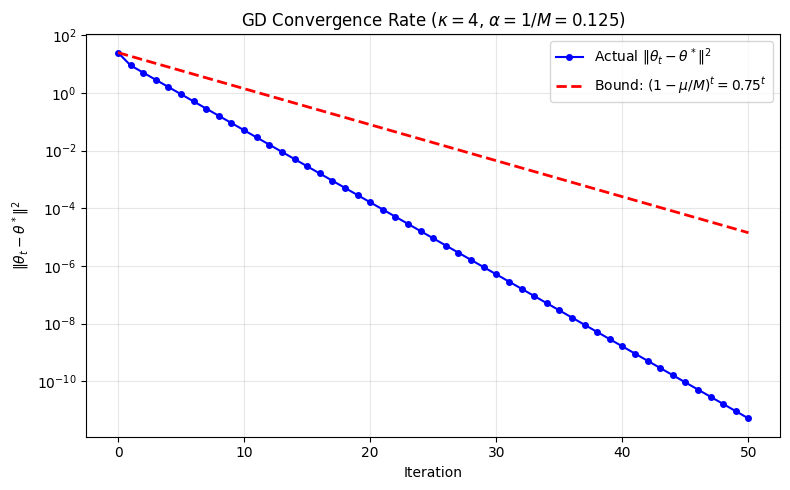

Condition number κ = 4
Convergence rate = 0.75
All errors ≤ theoretical bound: ✓


In [4]:
# Verify convergence rate matches theory
M, mu = 8.0, 2.0
kappa = M / mu
alpha_opt = 1.0 / M

w = np.array([4.0, 3.0])
w_star = np.array([0.0, 0.0])
n_steps = 50

errors = [np.linalg.norm(w - w_star)**2]
for _ in range(n_steps):
    w = w - alpha_opt * grad_quad(w)
    errors.append(np.linalg.norm(w - w_star)**2)

errors = np.array(errors)

# Theoretical bound: (1 - mu/M)^t * ||w0 - w*||^2
rate = 1 - mu / M  # 0.75
theoretical_bound = errors[0] * rate ** np.arange(n_steps + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(errors, "bo-", markersize=4, label="Actual $\\|\\theta_t - \\theta^*\\|^2$")
ax.semilogy(theoretical_bound, "r--", linewidth=2,
            label=f"Bound: $(1 - \\mu/M)^t = {rate}^t$")
ax.set_xlabel("Iteration")
ax.set_ylabel("$\\|\\theta_t - \\theta^*\\|^2$")
ax.set_title(f"GD Convergence Rate ($\\kappa = {kappa:.0f}$, $\\alpha = 1/M = {alpha_opt}$)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify actual errors are below theoretical bound
assert np.all(errors <= theoretical_bound + 1e-10), "Errors should not exceed bound!"
print(f"Condition number κ = {kappa:.0f}")
print(f"Convergence rate = {rate}")
print(f"All errors ≤ theoretical bound: ✓")

---
## 4. Implementation — BUILD

### 4.1 Vanilla Gradient Descent (from scratch)

In [5]:
def gd_scratch(grad_fn, x0, lr=0.01, max_iter=1000, tol=1e-6):
    """Vanilla gradient descent from scratch.

    Args:
        grad_fn: function returning the gradient at a point
        x0: initial point (1D array)
        lr: learning rate
        max_iter: maximum number of iterations
        tol: stop when ||x_new - x|| < tol

    Returns:
        x: final point
        history: list of all iterates
    """
    x = np.asarray(x0, dtype=float).copy()
    history = [x.copy()]
    for _ in range(max_iter):
        g = grad_fn(x)
        x_new = x - lr * g
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history


# Test: minimize f(x,y) = x^2 + 4y^2, minimum at (0, 0)
w_opt, hist = gd_scratch(grad_quad, np.array([4.0, 3.0]), lr=0.1, max_iter=200)
print(f"GD result: [{w_opt[0]:.8f}, {w_opt[1]:.8f}]")
print(f"f(w_opt) = {f_quad(w_opt):.10f}")
assert np.allclose(w_opt, [0.0, 0.0], atol=1e-4), "GD should converge to (0, 0)"

GD result: [0.00000392, 0.00000000]
f(w_opt) = 0.0000000000


### 4.2 Momentum GD (Polyak heavy-ball)

In [6]:
def gd_momentum_scratch(grad_fn, x0, lr=0.01, beta=0.9, max_iter=1000, tol=1e-6):
    """Gradient descent with Polyak heavy-ball momentum.

    Update:
        v = beta * v - lr * grad
        x = x + v
    """
    x = np.asarray(x0, dtype=float).copy()
    v = np.zeros_like(x)
    history = [x.copy()]
    for _ in range(max_iter):
        g = grad_fn(x)
        v = beta * v - lr * g
        x_new = x + v
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history


w_mom, hist_mom = gd_momentum_scratch(
    grad_quad, np.array([4.0, 3.0]), lr=0.05, beta=0.9, max_iter=200
)
print(f"Momentum GD result: [{w_mom[0]:.8f}, {w_mom[1]:.8f}]")
assert np.allclose(w_mom, [0.0, 0.0], atol=1e-4), "Momentum GD should converge to (0, 0)"

Momentum GD result: [0.00000558, 0.00008173]


### 4.3 Adam (from scratch)

In [7]:
def adam_scratch(grad_fn, x0, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8,
                max_iter=1000, tol=1e-6):
    """Adam optimizer from scratch with bias correction.

    Update:
        m = beta1 * m + (1 - beta1) * grad       (first moment)
        s = beta2 * s + (1 - beta2) * grad**2    (second moment)
        m_hat = m / (1 - beta1^t)                (bias-corrected)
        s_hat = s / (1 - beta2^t)
        x = x - lr * m_hat / (sqrt(s_hat) + eps)
    """
    x = np.asarray(x0, dtype=float).copy()
    m = np.zeros_like(x)  # first moment
    s = np.zeros_like(x)  # second moment
    history = [x.copy()]

    for t in range(1, max_iter + 1):
        g = grad_fn(x)
        m = beta1 * m + (1 - beta1) * g
        s = beta2 * s + (1 - beta2) * g**2
        # Bias correction
        m_hat = m / (1 - beta1**t)
        s_hat = s / (1 - beta2**t)
        x_new = x - lr * m_hat / (np.sqrt(s_hat) + eps)
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history


w_adam, hist_adam = adam_scratch(
    grad_quad, np.array([4.0, 3.0]), lr=0.1, max_iter=500
)
print(f"Adam result: [{w_adam[0]:.8f}, {w_adam[1]:.8f}]")
assert np.allclose(w_adam, [0.0, 0.0], atol=1e-3), "Adam should converge to (0, 0)"

Adam result: [-0.00002234, -0.00001083]


### 4.4 SGD on a Regression Problem

In [8]:
def sgd_scratch(grad_batch_fn, x0, n_samples, lr=0.01, max_iter=100,
                batch_size=32, rng=None):
    """Mini-batch SGD from scratch.

    Args:
        grad_batch_fn: function(x, batch_indices) → gradient estimate
        n_samples: total number of training samples
        batch_size: mini-batch size
    """
    if rng is None:
        rng = np.random.default_rng(42)
    x = np.asarray(x0, dtype=float).copy()
    history = [x.copy()]

    for epoch in range(max_iter):
        indices = rng.permutation(n_samples)
        for start in range(0, n_samples, batch_size):
            batch = indices[start:start + batch_size]
            g = grad_batch_fn(x, batch)
            x = x - lr * g
        history.append(x.copy())

    return x, history


# Generate regression data: y = 3x1 + 2x2 + 1 + noise
n_samples = 200
X_data = rng.normal(size=(n_samples, 2))
true_w = np.array([3.0, 2.0])
true_b = 1.0
y_data = X_data @ true_w + true_b + rng.normal(0, 0.5, size=n_samples)

# Add bias column
X_aug = np.column_stack([np.ones(n_samples), X_data])  # (n, 3)
true_params = np.array([true_b, true_w[0], true_w[1]])  # [1, 3, 2]

# MSE gradient for batch
def mse_grad_batch(w, batch_idx):
    X_b = X_aug[batch_idx]
    y_b = y_data[batch_idx]
    residuals = X_b @ w - y_b
    return (2.0 / len(batch_idx)) * (X_b.T @ residuals)

# Full-batch MSE gradient for comparison
def mse_grad_full(w):
    residuals = X_aug @ w - y_data
    return (2.0 / n_samples) * (X_aug.T @ residuals)

# Run SGD
w0 = np.zeros(3)
sgd_rng = np.random.default_rng(SEED)
w_sgd, hist_sgd = sgd_scratch(
    mse_grad_batch, w0, n_samples, lr=0.01, max_iter=50, batch_size=32, rng=sgd_rng
)

# Also run full-batch GD for comparison
w_gd_reg, hist_gd_reg = gd_scratch(mse_grad_full, w0, lr=0.01, max_iter=200)

# Analytical solution via normal equation
w_analytical = np.linalg.lstsq(X_aug, y_data, rcond=None)[0]

print(f"True params:      {true_params}")
print(f"Analytical (OLS): [{w_analytical[0]:.4f}, {w_analytical[1]:.4f}, {w_analytical[2]:.4f}]")
print(f"Full-batch GD:    [{w_gd_reg[0]:.4f}, {w_gd_reg[1]:.4f}, {w_gd_reg[2]:.4f}]")
print(f"Mini-batch SGD:   [{w_sgd[0]:.4f}, {w_sgd[1]:.4f}, {w_sgd[2]:.4f}]")

True params:      [1. 3. 2.]
Analytical (OLS): [0.9653, 2.9911, 1.9733]
Full-batch GD:    [0.9470, 2.9441, 1.9182]
Mini-batch SGD:   [0.9628, 2.9835, 1.9636]


### 4.5 Momentum Visualization — Acceleration on Elongated Surfaces

The quadratic $f(x,y) = x^2 + 50y^2$ has condition number $\kappa = 50$.
Vanilla GD zig-zags badly; momentum smooths the trajectory.

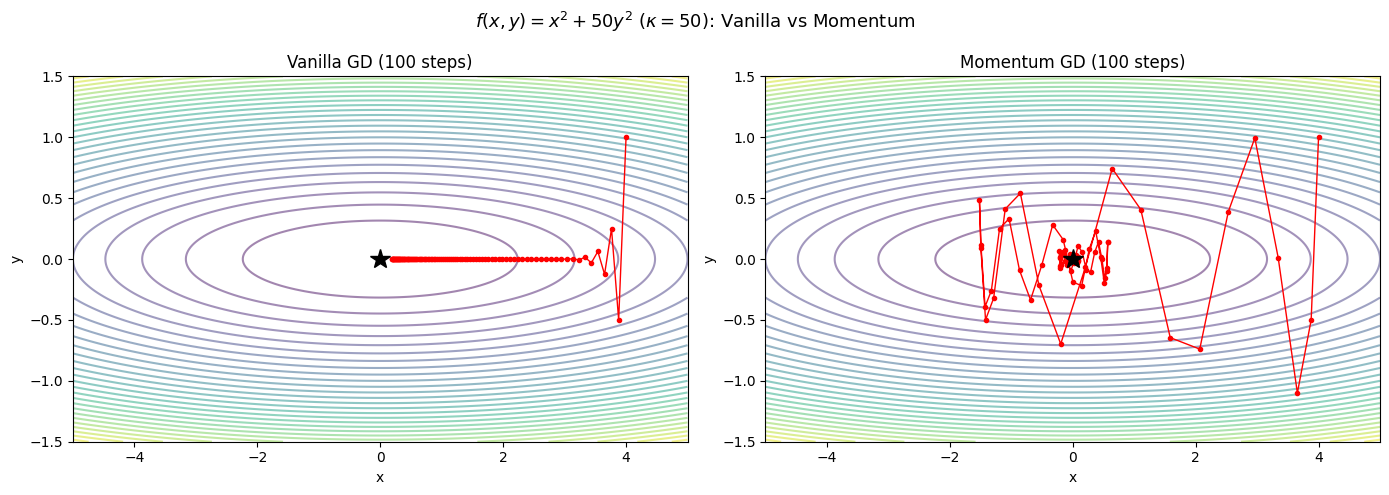

Vanilla GD final f = 3.617986e-02 (after 100 steps)
Momentum GD final f = 1.607507e-04 (after 100 steps)


In [9]:
# Highly elongated surface: kappa = 50
def f_elongated(w):
    return w[0]**2 + 50 * w[1]**2

def grad_elongated(w):
    return np.array([2 * w[0], 100 * w[1]])

w0_elong = np.array([4.0, 1.0])

# Vanilla GD
_, hist_vanilla = gd_scratch(grad_elongated, w0_elong, lr=0.015, max_iter=100, tol=1e-10)

# Momentum GD
_, hist_momentum = gd_momentum_scratch(
    grad_elongated, w0_elong, lr=0.015, beta=0.9, max_iter=100, tol=1e-10
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

xx2, yy2 = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-1.5, 1.5, 200))
zz2 = xx2**2 + 50 * yy2**2

for ax, hist, title in [
    (axes[0], hist_vanilla, f"Vanilla GD ({len(hist_vanilla)-1} steps)"),
    (axes[1], hist_momentum, f"Momentum GD ({len(hist_momentum)-1} steps)"),
]:
    h = np.array(hist)
    ax.contour(xx2, yy2, zz2, levels=30, cmap="viridis", alpha=0.5)
    ax.plot(h[:, 0], h[:, 1], "ro-", markersize=3, linewidth=1)
    ax.plot(0, 0, "k*", markersize=15)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("$f(x,y) = x^2 + 50y^2$ ($\\kappa = 50$): Vanilla vs Momentum", fontsize=13)
plt.tight_layout()
plt.show()

# Show that momentum converges faster
val_v = [f_elongated(np.array(h)) for h in hist_vanilla]
val_m = [f_elongated(np.array(h)) for h in hist_momentum]
print(f"Vanilla GD final f = {val_v[-1]:.6e} (after {len(val_v)-1} steps)")
print(f"Momentum GD final f = {val_m[-1]:.6e} (after {len(val_m)-1} steps)")

---
## 5. Library Comparison

Compare our from-scratch implementations with the `ml_first_principles.optimizers` library.

In [10]:
from ml_first_principles.optimizers import gradient_descent, adam

# Compare on the quadratic f(x,y) = x^2 + 4y^2
w0_test = np.array([4.0, 3.0])

# From-scratch GD
w_scratch, _ = gd_scratch(grad_quad, w0_test, lr=0.1, max_iter=200)

# Library GD
w_lib, _ = gradient_descent(grad_quad, w0_test, lr=0.1, max_iter=200)

print("=== GD Comparison ===")
print(f"Scratch: [{w_scratch[0]:.10f}, {w_scratch[1]:.10f}]")
print(f"Library: [{w_lib[0]:.10f}, {w_lib[1]:.10f}]")
assert np.allclose(w_scratch, w_lib, atol=1e-8), "Scratch and library GD should match"
print("Match: ✓")

# Compare Adam
w_adam_scratch, _ = adam_scratch(grad_quad, w0_test, lr=0.1, max_iter=500)
w_adam_lib, _ = adam(grad_quad, w0_test, lr=0.1, max_iter=500)

print("\n=== Adam Comparison ===")
print(f"Scratch: [{w_adam_scratch[0]:.10f}, {w_adam_scratch[1]:.10f}]")
print(f"Library: [{w_adam_lib[0]:.10f}, {w_adam_lib[1]:.10f}]")
assert np.allclose(w_adam_scratch, w_adam_lib, atol=1e-6), "Scratch and library Adam should match"
print("Match: ✓")

=== GD Comparison ===
Scratch: [0.0000039232, 0.0000000000]
Library: [0.0000039232, 0.0000000000]
Match: ✓

=== Adam Comparison ===
Scratch: [-0.0000223408, -0.0000108254]
Library: [-0.0000223408, -0.0000108254]
Match: ✓


In [11]:
# Deterministic check: compare GD solution to known analytical minimum
# f(x,y) = (x-2)^2 + 4(y+1)^2 → minimum at (2, -1)
def grad_shifted(w):
    return np.array([2 * (w[0] - 2), 8 * (w[1] + 1)])

w_shifted, _ = gd_scratch(grad_shifted, np.array([0.0, 0.0]), lr=0.1, max_iter=500)

print(f"GD found: [{w_shifted[0]:.6f}, {w_shifted[1]:.6f}]")
print(f"Expected: [2.000000, -1.000000]")
assert np.allclose(w_shifted, [2.0, -1.0], atol=1e-4), "Should find (2, -1)"
print("Deterministic check: ✓")

GD found: [1.999996, -1.000000]
Expected: [2.000000, -1.000000]
Deterministic check: ✓


---
## 6. Experiments and Failures — VERIFY

### 6.1 Convergence Race: GD vs Momentum vs Adam

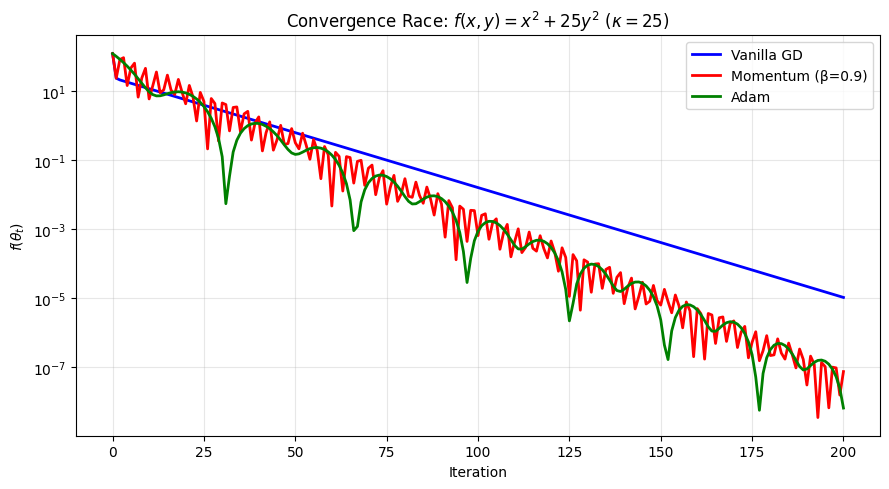

Final values after 200 iterations:
  GD:       1.068448e-05
  Momentum: 7.570510e-08
  Adam:     6.634201e-09


In [12]:
# Race on a moderately ill-conditioned quadratic
# f(x,y) = x^2 + 25y^2, kappa = 25
def f_race(w):
    return w[0]**2 + 25 * w[1]**2

def grad_race(w):
    return np.array([2 * w[0], 50 * w[1]])

w0_race = np.array([5.0, 2.0])

# Run all three
_, hist_gd = gd_scratch(grad_race, w0_race, lr=0.018, max_iter=200, tol=1e-12)
_, hist_mom = gd_momentum_scratch(grad_race, w0_race, lr=0.018, beta=0.9, max_iter=200, tol=1e-12)
_, hist_adam_r = adam_scratch(grad_race, w0_race, lr=0.2, max_iter=200, tol=1e-12)

# Compute objective values
vals_gd = [f_race(np.array(h)) for h in hist_gd]
vals_mom = [f_race(np.array(h)) for h in hist_mom]
vals_adam = [f_race(np.array(h)) for h in hist_adam_r]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(vals_gd, "b-", linewidth=2, label="Vanilla GD")
ax.semilogy(vals_mom, "r-", linewidth=2, label="Momentum (β=0.9)")
ax.semilogy(vals_adam, "g-", linewidth=2, label="Adam")
ax.set_xlabel("Iteration")
ax.set_ylabel("$f(\\theta_t)$")
ax.set_title("Convergence Race: $f(x,y) = x^2 + 25y^2$ ($\\kappa = 25$)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final values after {len(vals_gd)-1} iterations:")
print(f"  GD:       {vals_gd[-1]:.6e}")
print(f"  Momentum: {vals_mom[-1]:.6e}")
print(f"  Adam:     {vals_adam[-1]:.6e}")

### 6.2 Failure Case: Saddle Point

Consider $f(x,y) = x^2 - y^2$. The point $(0, 0)$ is a **saddle point**:
$\nabla f = 0$ but the Hessian has eigenvalues $+2$ and $-2$.

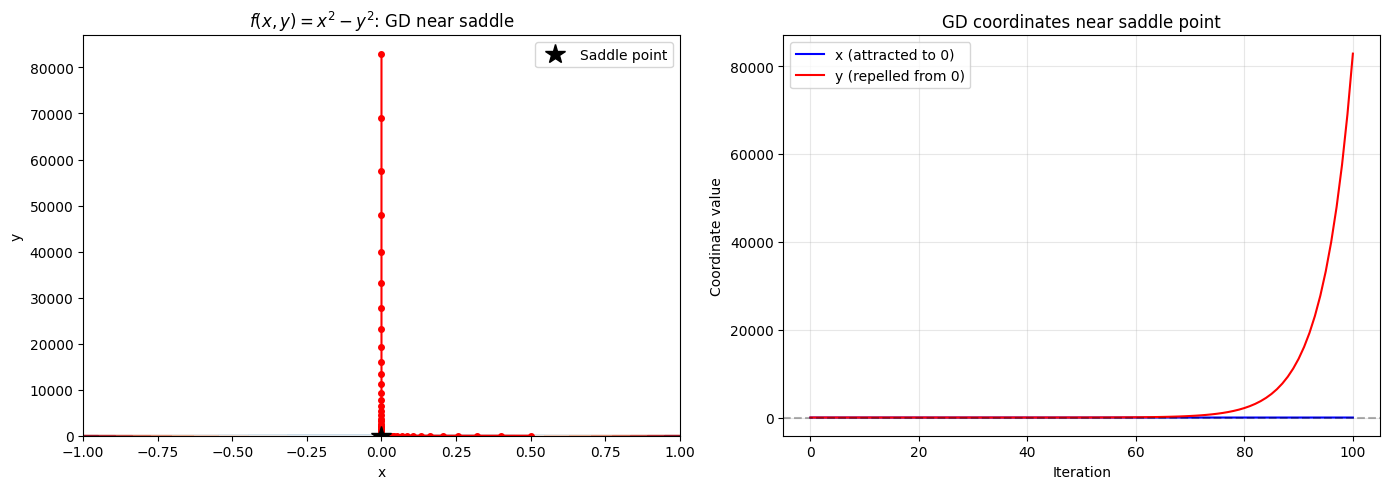

GD ended at: [1.018518e-10, 8.281797e+04]
x → 0 (attracted along positive curvature)
y → diverges (repelled along negative curvature)
GD does NOT converge to the saddle; the unstable direction eventually dominates.


In [13]:
# Saddle point: f(x,y) = x^2 - y^2
def f_saddle(w):
    return w[0]**2 - w[1]**2

def grad_saddle(w):
    return np.array([2 * w[0], -2 * w[1]])

# Starting near the saddle along the x-axis → GD gets attracted to saddle
w0_saddle = np.array([0.5, 0.001])  # tiny y perturbation
w_saddle, hist_saddle = gd_scratch(grad_saddle, w0_saddle, lr=0.1, max_iter=100, tol=1e-12)

h_saddle = np.array(hist_saddle)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contour plot with trajectory
xx3, yy3 = np.meshgrid(np.linspace(-1, 1, 200), np.linspace(-1, 1, 200))
zz3 = xx3**2 - yy3**2
axes[0].contour(xx3, yy3, zz3, levels=20, cmap="RdBu_r", alpha=0.6)
axes[0].plot(h_saddle[:, 0], h_saddle[:, 1], "ro-", markersize=4, linewidth=1.5)
axes[0].plot(0, 0, "k*", markersize=15, label="Saddle point")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("$f(x,y) = x^2 - y^2$: GD near saddle")
axes[0].legend()

# x and y coordinates vs iteration
axes[1].plot(h_saddle[:, 0], "b-", label="x (attracted to 0)")
axes[1].plot(h_saddle[:, 1], "r-", label="y (repelled from 0)")
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Coordinate value")
axes[1].set_title("GD coordinates near saddle point")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GD ended at: [{w_saddle[0]:.6e}, {w_saddle[1]:.6e}]")
print("x → 0 (attracted along positive curvature)")
print("y → diverges (repelled along negative curvature)")
print("GD does NOT converge to the saddle; the unstable direction eventually dominates.")

### 6.3 Failure Case: Learning Rate Too Large → Divergence

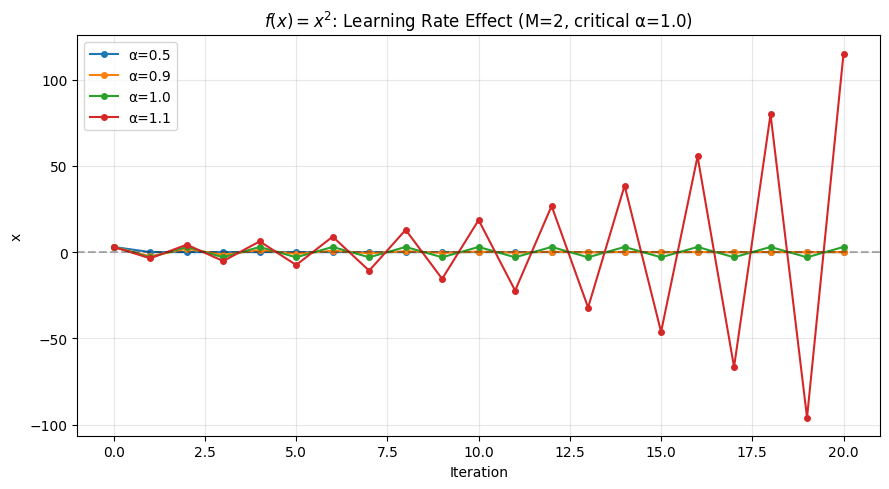

α < 1.0 → converges
α = 1.0 → oscillates between +3 and -3 (boundary)
α > 1.0 → diverges


In [14]:
# f(x) = x^2, gradient = 2x, M = 2, critical alpha = 1.0
def grad_1d(x):
    return np.array([2 * x[0]])

alphas = [0.5, 0.9, 1.0, 1.1]

fig, ax = plt.subplots(figsize=(9, 5))
for lr in alphas:
    x = np.array([3.0])
    vals = [x[0]]
    for _ in range(20):
        x = x - lr * grad_1d(x)
        if abs(x[0]) > 1e6:
            break
        vals.append(x[0])
    ax.plot(vals, "o-", markersize=4, label=f"α={lr}")

ax.axhline(0, color="k", linestyle="--", alpha=0.3)
ax.set_xlabel("Iteration")
ax.set_ylabel("x")
ax.set_title("$f(x) = x^2$: Learning Rate Effect (M=2, critical α=1.0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("α < 1.0 → converges")
print("α = 1.0 → oscillates between +3 and -3 (boundary)")
print("α > 1.0 → diverges")

### 6.4 SGD Noise and Learning Rate Schedule

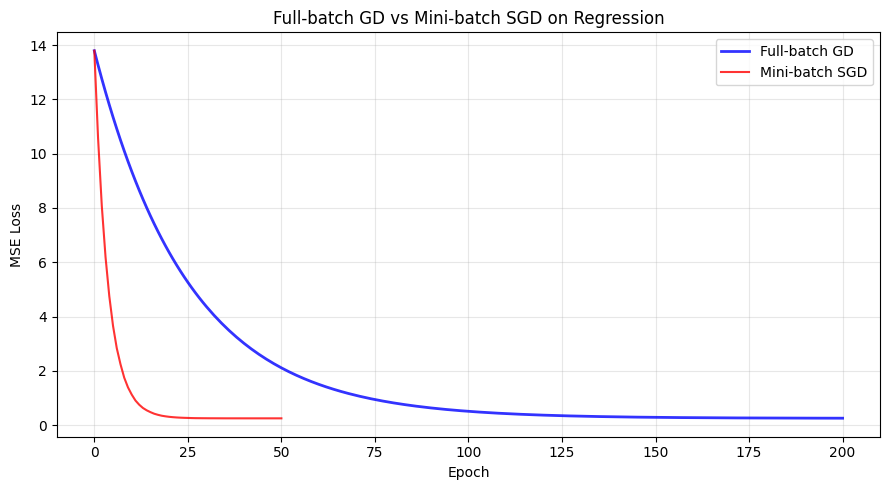

Final MSE — GD: 0.261605, SGD: 0.256482
Analytical min MSE: 0.256333


In [15]:
# Compare full-batch GD loss curve vs SGD loss curve on the regression problem
# Full-batch GD: smooth convergence
# SGD: noisy convergence

def mse_loss(w):
    residuals = X_aug @ w - y_data
    return np.mean(residuals**2)

# Full GD loss history
loss_gd = [mse_loss(np.array(h)) for h in hist_gd_reg]

# SGD loss history
loss_sgd = [mse_loss(np.array(h)) for h in hist_sgd]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_gd, "b-", linewidth=2, label="Full-batch GD", alpha=0.8)
ax.plot(loss_sgd, "r-", linewidth=1.5, label="Mini-batch SGD", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Full-batch GD vs Mini-batch SGD on Regression")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final MSE — GD: {loss_gd[-1]:.6f}, SGD: {loss_sgd[-1]:.6f}")
print(f"Analytical min MSE: {mse_loss(w_analytical):.6f}")

---
## 7. Connections

| Topic | Relationship |
|---|---|
| **01 Linear Regression** | GD is the iterative alternative to the normal equation |
| **03 Regularization** | Adding $\lambda\Vert \theta\Vert^2$ improves condition number $\kappa$ |
| **04 Logistic Regression** | No closed form → GD is the standard solver |
| **13 Neural Networks** | Backprop computes gradients; SGD/Adam optimizes the weights |
| **Optimization Synthesis** | Compares GD, Newton, coordinate descent, etc. |

### Takeaway

Gradient descent is the engine behind almost every ML model. The key insights:

1. **Learning rate** must satisfy $\alpha < 2/M$ for convergence
2. **Condition number** $\kappa = M/\mu$ determines speed; momentum helps when $\kappa \gg 1$
3. **SGD** trades noise for speed (per-iteration cost $O(Bd)$ vs $O(nd)$)
4. **Adam** combines momentum + adaptive rates for robust practical performance
5. **Failure modes** include divergence, saddle points, and ill-conditioning — know them